# Phase 3: สำรวจข้อมูล (EDA) ก่อน train

เอกสาร หัวข้อ 15 Phase 3 ข้อ 5 และ Gate: feature ต้องมีสัญญาณแยก onset ได้จริง (AUC ของ feature เดี่ยว > 0.6)

Input: `labeled.parquet` จาก `scripts/build_labels.py` (หรือ `labeled_all.parquet` ที่สร้างจาก demo)

In [5]:
import sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from convrain.features import MODEL_FEATURES
from convrain.evaluate import at_risk_rows, event_within
LABELED = '../runs/2025/timeseries_all.parquet'  # แก้เป็น path ของคุณ
df = pd.read_parquet(LABELED)
df['time'] = pd.to_datetime(df['time'], utc=True)
print(len(df), 'แถว', df.object_id.nunique(), 'track')

3305 แถว 396 track


In [7]:
import pandas as pd

# 1. โหลดข้อมูลทั้งสองไฟล์
df_ts = pd.read_parquet('../runs/2025/timeseries_all.parquet')
df_label = pd.read_parquet('../runs/2025/labels.parquet')

# 2. รวมร่างข้อมูล (Merge) เข้าด้วยกันโดยใช้ object_id เป็นตัวเชื่อม
df = pd.merge(df_ts, df_label, on='object_id', how='inner')

# 3. จัดการเรื่องเวลา
df['time'] = pd.to_datetime(df['time'], utc=True)

print(len(df), 'แถว', df.object_id.nunique(), 'track')

3305 แถว 396 track


## 1. ภาพรวมของ label

track ที่มี onset      : 224
onset ตั้งแต่เกิด       : 56


c:\Users\ASUS\miniconda3\envs\convrain\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\miniconda3\envs\convrain\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\miniconda3\envs\convrain\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\miniconda3\envs\convrain\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ASUS\miniconda3\envs\convrain\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHAR

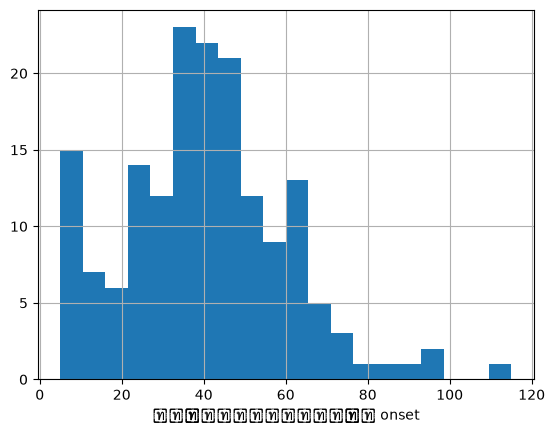

In [8]:
tr = df.groupby('object_id').agg(t_onset=('t_onset','first'), birth=('time','min'), onset_at_birth=('onset_at_birth','first'),
                                  min_bt=('min_cold_bt_track','last'))
print('track ที่มี onset      :', tr.t_onset.notna().sum())
print('onset ตั้งแต่เกิด       :', tr.onset_at_birth.sum())
# lead time สูงสุดที่เป็นไปได้ = เวลาจากตรวจพบครั้งแรกถึง onset
lead = (pd.to_datetime(tr.t_onset, utc=True) - tr.birth).dt.total_seconds() / 60
lead[lead > 0].hist(bins=20); plt.xlabel('นาทีจากตรวจพบถึง onset'); plt.show()

## 2. สัดส่วน warm-rain onset (หัวข้อ 12 ข้อ 1)

onset ที่เกิดขณะ BT แกนเย็นยังอุ่นกว่า 253 K

In [9]:
pre = at_risk_rows(df).sort_values('time').groupby('object_id').last()
has = pre.t_onset.notna()
warm = (pre.loc[has, 'cold_bt'] > 253).mean()
print(f'warm-rain onset ≈ {warm:.1%} ของ onset ทั้งหมด')

warm-rain onset ≈ 26.8% ของ onset ทั้งหมด


## 3. AUC ของ feature เดี่ยว (Gate ของ Phase 3)

เป้าหมาย: onset ภายใน 30 นาที ใช้เฉพาะแถวที่ยังไม่เกิด onset

In [10]:
d = at_risk_rows(df)
y = event_within(d, 30)
rows = []
for f in MODEL_FEATURES:
    x = d[f].values.astype(float)
    ok = np.isfinite(x)
    if ok.sum() > 50 and len(np.unique(y[ok])) == 2:
        auc = roc_auc_score(y[ok], x[ok])
        rows.append((f, max(auc, 1 - auc), ok.mean()))
auc = pd.DataFrame(rows, columns=['feature', 'AUC', 'coverage']).sort_values('AUC', ascending=False)
auc

,feature,AUC,coverage
18,d_btd_wv_30,0.932705,0.444375
19,d_btd_co2_30,0.931750,0.444375
9,d_cold_bt_30,0.928223,0.444375
8,d_cold_bt_20,0.925098,0.605280
23,d_ttd_30,0.921560,0.444375
17,d_btd_wv_10,0.911881,0.786298
7,d_cold_bt_10,0.898105,0.786298
5,cooling_rate_kf,0.853318,1.000000
22,d_ttd_10,0.830399,0.786298
15,btd_73_cold,0.820461,1.000000


## 4. การกระจายของ feature: ก่อน onset vs ไม่มีฝน

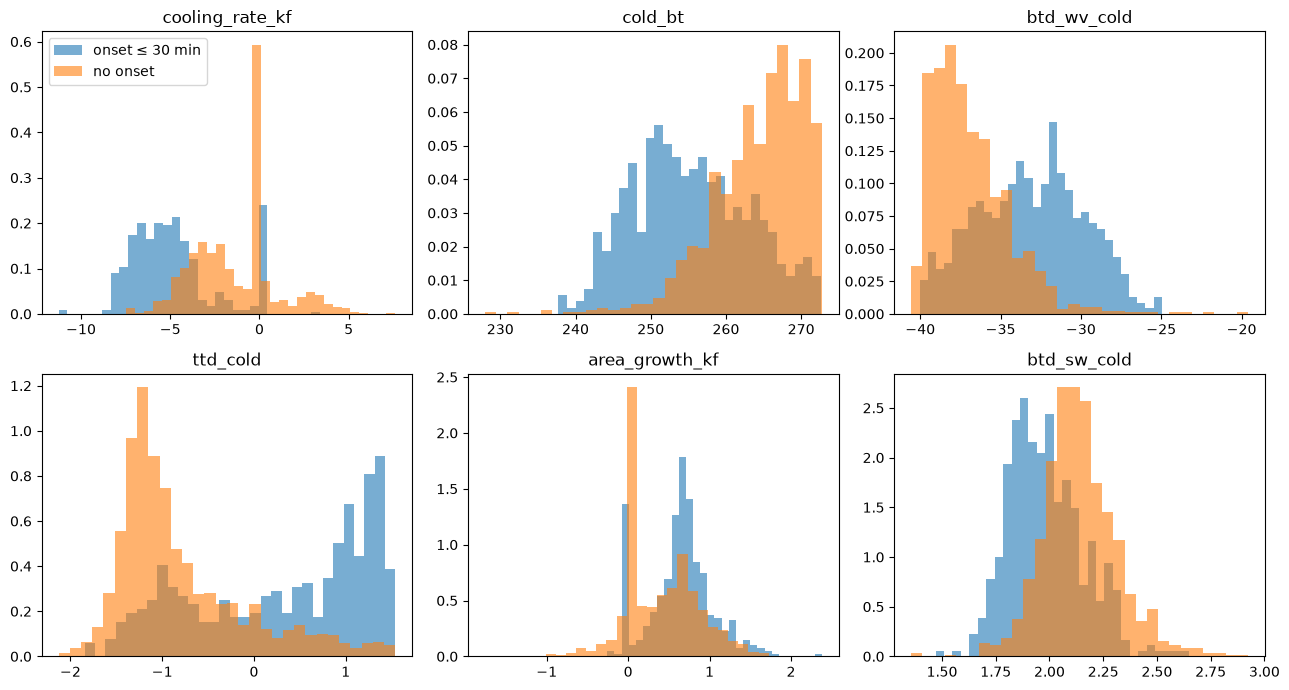

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), ['cooling_rate_kf', 'cold_bt', 'btd_wv_cold', 'ttd_cold', 'area_growth_kf', 'btd_sw_cold']):
    ax.hist(d.loc[y == 1, f].dropna(), bins=30, alpha=.6, density=True, label='onset ≤ 30 min')
    ax.hist(d.loc[y == 0, f].dropna(), bins=30, alpha=.6, density=True, label='no onset')
    ax.set_title(f)
axes[0, 0].legend(); plt.tight_layout(); plt.show()